In [8]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

RAW_DIR = Path('../data/raw')          # ← adjust if needed
CSV_FILES = sorted(RAW_DIR.glob('*.csv'))

print(f'Found {len(CSV_FILES)} CSV files:')
for f in CSV_FILES:
    size_mb = f.stat().st_size / 1e6
    print(f'  {f.name:50s}  {size_mb:7.1f} MB')

Found 10 CSV files:
  Friday-02-03-2018_TrafficForML_CICFlowMeter.csv       352.4 MB
  Friday-16-02-2018_TrafficForML_CICFlowMeter.csv       333.7 MB
  Friday-23-02-2018_TrafficForML_CICFlowMeter.csv       382.8 MB
  Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv    4054.9 MB
  Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv     107.8 MB
  Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv     375.9 MB
  Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv     382.6 MB
  Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv    358.2 MB
  Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv    328.9 MB
  Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv    209.2 MB


In [9]:
headers = {}
for f in CSV_FILES:
    cols = pd.read_csv(f, nrows=0).columns.tolist()
    headers[f.name] = cols

# Reference column set
ref_cols = set(headers[CSV_FILES[0].name])

print('=== Column count per file ===')
for name, cols in headers.items():
    diff = set(cols).symmetric_difference(ref_cols)
    flag = '  ⚠ DIFF: ' + str(diff) if diff else '  ✓'
    print(f'  {name:50s}  {len(cols)} cols{flag}')

print()
# Identify label column
ref_list = headers[CSV_FILES[0].name]
label_candidates = [c for c in ref_list if 'label' in c.lower()]
print(f'Label column candidates: {label_candidates}')
print(f'All columns in first file:')
for i, c in enumerate(ref_list):
    print(f'  [{i:2d}] "{c}"')

=== Column count per file ===
  Friday-02-03-2018_TrafficForML_CICFlowMeter.csv     80 cols  ✓
  Friday-16-02-2018_TrafficForML_CICFlowMeter.csv     80 cols  ✓
  Friday-23-02-2018_TrafficForML_CICFlowMeter.csv     80 cols  ✓
  Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv   84 cols  ⚠ DIFF: {'Flow ID', 'Dst IP', 'Src Port', 'Src IP'}
  Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv   80 cols  ✓
  Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv   80 cols  ✓
  Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv   80 cols  ✓
  Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv  80 cols  ✓
  Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv  80 cols  ✓
  Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv  80 cols  ✓

Label column candidates: ['Label']
All columns in first file:
  [ 0] "Dst Port"
  [ 1] "Protocol"
  [ 2] "Timestamp"
  [ 3] "Flow Duration"
  [ 4] "Tot Fwd Pkts"
  [ 5] "Tot Bwd Pkts"
  [ 6] "TotLen Fwd Pkts"
  [ 7] "TotLen Bwd Pkts"
  [ 8] "Fwd Pkt Len Max"
  [ 9] "Fw

In [10]:
# Detect label column name automatically
LABEL_COL = label_candidates[0]   # adjust index if wrong
print(f'Using label column: "{LABEL_COL}"\n')

per_file_counts = {}
global_counts   = {}

for f in CSV_FILES:
    labels = pd.read_csv(f, usecols=[LABEL_COL])[LABEL_COL]
    vc = labels.value_counts()
    per_file_counts[f.name] = vc
    for lbl, cnt in vc.items():
        global_counts[lbl] = global_counts.get(lbl, 0) + cnt

print('=== Per-file label distribution ===')
for fname, vc in per_file_counts.items():
    total = vc.sum()
    print(f'\n{fname}  (total rows: {total:,})')
    for lbl, cnt in vc.items():
        pct = cnt / total * 100
        print(f'  {lbl:40s}  {cnt:>8,}  ({pct:5.1f}%)')

print('\n=== GLOBAL label distribution ===')
total_global = sum(global_counts.values())
for lbl, cnt in sorted(global_counts.items(), key=lambda x: -x[1]):
    pct = cnt / total_global * 100
    print(f'  {lbl:40s}  {cnt:>9,}  ({pct:5.1f}%)')
print(f'\n  TOTAL: {total_global:,}')

Using label column: "Label"

=== Per-file label distribution ===

Friday-02-03-2018_TrafficForML_CICFlowMeter.csv  (total rows: 1,048,575)
  Benign                                     762,384  ( 72.7%)
  Bot                                        286,191  ( 27.3%)

Friday-16-02-2018_TrafficForML_CICFlowMeter.csv  (total rows: 1,048,575)
  DoS attacks-Hulk                           461,912  ( 44.1%)
  Benign                                     446,772  ( 42.6%)
  DoS attacks-SlowHTTPTest                   139,890  ( 13.3%)
  Label                                            1  (  0.0%)

Friday-23-02-2018_TrafficForML_CICFlowMeter.csv  (total rows: 1,048,575)
  Benign                                    1,048,009  ( 99.9%)
  Brute Force -Web                               362  (  0.0%)
  Brute Force -XSS                               151  (  0.0%)
  SQL Injection                                   53  (  0.0%)

Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv  (total rows: 7,948,748)
  Beni

In [11]:
BENIGN_LABEL   = 'Benign'   
BENIGN_CAP     = 100_000

sampled_benign  = 0
sampled_attack  = 0
attack_per_file = {}

for f in CSV_FILES:
    labels = pd.read_csv(f, usecols=[LABEL_COL])[LABEL_COL]
    n_benign = (labels == BENIGN_LABEL).sum()
    n_attack = (labels != BENIGN_LABEL).sum()
    take_benign = min(n_benign, BENIGN_CAP)
    sampled_benign += take_benign
    sampled_attack += n_attack
    attack_per_file[f.name] = n_attack
    print(f'{f.name:50s}  benign: {n_benign:>8,} → take {take_benign:>7,}  |  attack: {n_attack:>7,} → take all')

print(f'\nProjected dataset size:')
print(f'  Benign  rows : {sampled_benign:>8,}')
print(f'  Attack  rows : {sampled_attack:>8,}')
print(f'  TOTAL        : {sampled_benign + sampled_attack:>8,}')
print(f'  Attack ratio : {sampled_attack / (sampled_benign + sampled_attack) * 100:.1f}%')

Friday-02-03-2018_TrafficForML_CICFlowMeter.csv     benign:  762,384 → take 100,000  |  attack: 286,191 → take all
Friday-16-02-2018_TrafficForML_CICFlowMeter.csv     benign:  446,772 → take 100,000  |  attack: 601,803 → take all
Friday-23-02-2018_TrafficForML_CICFlowMeter.csv     benign: 1,048,009 → take 100,000  |  attack:     566 → take all
Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv   benign: 7,372,557 → take 100,000  |  attack: 576,191 → take all
Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv   benign:  238,037 → take 100,000  |  attack:  93,088 → take all
Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv   benign:  996,077 → take 100,000  |  attack:  52,498 → take all
Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv   benign: 1,048,213 → take 100,000  |  attack:     362 → take all
Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv  benign:  667,626 → take 100,000  |  attack: 380,949 → take all
Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv  benign:  360,833 → take 1

In [12]:
frames = []

for f in CSV_FILES:
    df_file = pd.read_csv(f, low_memory=False)
    
    # Strip whitespace from column names (CIC datasets often have leading spaces)
    df_file.columns = df_file.columns.str.strip()
    
    # Strip whitespace from label values
    df_file[LABEL_COL] = df_file[LABEL_COL].str.strip()
    
    benign_mask  = df_file[LABEL_COL] == BENIGN_LABEL
    attack_mask  = ~benign_mask
    
    benign_sample = df_file[benign_mask].sample(
        n=min(BENIGN_CAP, benign_mask.sum()), random_state=42
    )
    attack_all = df_file[attack_mask]
    
    frames.append(pd.concat([benign_sample, attack_all], ignore_index=True))
    print(f'Loaded {f.name}: {len(benign_sample):,} benign + {len(attack_all):,} attack')

df = pd.concat(frames, ignore_index=True)
df.columns = df.columns.str.strip()   # re-strip after concat
df[LABEL_COL] = df[LABEL_COL].str.strip()

print(f'\nFinal DataFrame shape: {df.shape}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Loaded Friday-02-03-2018_TrafficForML_CICFlowMeter.csv: 100,000 benign + 286,191 attack
Loaded Friday-16-02-2018_TrafficForML_CICFlowMeter.csv: 100,000 benign + 601,803 attack
Loaded Friday-23-02-2018_TrafficForML_CICFlowMeter.csv: 100,000 benign + 566 attack
Loaded Thuesday-20-02-2018_TrafficForML_CICFlowMeter.csv: 100,000 benign + 576,191 attack
Loaded Thursday-01-03-2018_TrafficForML_CICFlowMeter.csv: 100,000 benign + 93,088 attack
Loaded Thursday-15-02-2018_TrafficForML_CICFlowMeter.csv: 100,000 benign + 52,498 attack
Loaded Thursday-22-02-2018_TrafficForML_CICFlowMeter.csv: 100,000 benign + 362 attack
Loaded Wednesday-14-02-2018_TrafficForML_CICFlowMeter.csv: 100,000 benign + 380,949 attack
Loaded Wednesday-21-02-2018_TrafficForML_CICFlowMeter.csv: 100,000 benign + 687,742 attack
Loaded Wednesday-28-02-2018_TrafficForML_CICFlowMeter.csv: 100,000 benign + 68,904 attack

Final DataFrame shape: (3748294, 84)
Memory usage: 12414.5 MB


In [13]:
dtype_summary = df.dtypes.value_counts()
print('=== dtype counts ===')
print(dtype_summary)

object_cols = df.select_dtypes(include='object').columns.tolist()
# Remove label column from this list
object_cols_no_label = [c for c in object_cols if c != LABEL_COL]

print(f'\n=== Object (string) columns (excluding label): {len(object_cols_no_label)} ===')
for col in object_cols_no_label:
    n_unique = df[col].nunique()
    sample_vals = df[col].dropna().unique()[:5].tolist()
    print(f'  {col:40s}  unique={n_unique:5d}  samples={sample_vals}')

=== dtype counts ===
object     78
str         5
float64     1
Name: count, dtype: int64

=== Object (string) columns (excluding label): 82 ===
  Dst Port                                  unique=57379  samples=[443, 445, 53, 3389, 0]
  Protocol                                  unique=    7  samples=[6, 17, 0, '6', '0']
  Timestamp                                 unique=233764  samples=['02/03/2018 02:12:32', '02/03/2018 10:29:40', '02/03/2018 01:37:53', '02/03/2018 04:49:05', '02/03/2018 09:20:23']
  Flow Duration                             unique=1279879  samples=[115754899, 1105669, 253, 106162, 609]
  Tot Fwd Pkts                              unique= 3455  samples=[19, 6, 1, 3, 2]
  Tot Bwd Pkts                              unique= 1404  samples=[16, 5, 1, 0, 7]
  TotLen Fwd Pkts                           unique=13038  samples=[1658, 455, 41, 0, 45]
  TotLen Bwd Pkts                           unique=27039  samples=[1205.0, 338.0, 57.0, 0.0, 73.0]
  Fwd Pkt Len Max                  

In [14]:
numeric_df = df.select_dtypes(include=[np.number])

# NaN analysis
nan_counts = df.isnull().sum()
nan_cols   = nan_counts[nan_counts > 0].sort_values(ascending=False)

print('=== Columns with NaN values ===')
if len(nan_cols) == 0:
    print('  None found ✓')
else:
    for col, cnt in nan_cols.items():
        pct = cnt / len(df) * 100
        print(f'  {col:40s}  {cnt:>7,}  ({pct:5.1f}%)')

# Infinity analysis
inf_counts = np.isinf(numeric_df).sum()
inf_cols   = inf_counts[inf_counts > 0].sort_values(ascending=False)

print('\n=== Columns with Inf values ===')
if len(inf_cols) == 0:
    print('  None found ✓')
else:
    for col, cnt in inf_cols.items():
        pct = cnt / len(df) * 100
        print(f'  {col:40s}  {cnt:>7,}  ({pct:5.1f}%)')

print(f'\nTotal NaN  cells : {nan_counts.sum():,}')
print(f'Total Inf  cells : {inf_counts.sum():,}')

=== Columns with NaN values ===
  Flow ID                                   3,072,103  ( 82.0%)
  Src Port                                  3,072,103  ( 82.0%)
  Src IP                                    3,072,103  ( 82.0%)
  Dst IP                                    3,072,103  ( 82.0%)
  Flow Byts/s                                 4,542  (  0.1%)

=== Columns with Inf values ===
  None found ✓

Total NaN  cells : 12,292,954
Total Inf  cells : 0


In [15]:
numeric_df = df.select_dtypes(include=[np.number])

zero_var = []
near_zero_var = []

for col in numeric_df.columns:
    n_unique = numeric_df[col].nunique(dropna=True)
    if n_unique <= 1:
        zero_var.append(col)
    elif n_unique <= 5:
        near_zero_var.append((col, n_unique, numeric_df[col].value_counts().to_dict()))

print(f'=== Zero-variance columns (constant): {len(zero_var)} ===')
for c in zero_var:
    print(f'  {c}')

print(f'\n=== Near-zero variance (≤5 unique values): {len(near_zero_var)} ===')
for col, n, vd in near_zero_var:
    print(f'  {col:40s}  unique={n}  values={vd}')

=== Zero-variance columns (constant): 0 ===

=== Near-zero variance (≤5 unique values): 0 ===


In [16]:
# Replace inf with NaN for describe() to work
df_clean_preview = df.copy()
df_clean_preview.replace([np.inf, -np.inf], np.nan, inplace=True)

is_benign = df_clean_preview[LABEL_COL] == BENIGN_LABEL

desc_benign = df_clean_preview[is_benign].describe().T[['mean','std','min','max']]
desc_attack = df_clean_preview[~is_benign].describe().T[['mean','std','min','max']]

# Compute mean ratio: how different are attack vs benign means?
mean_ratio = (desc_attack['mean'] / (desc_benign['mean'].replace(0, np.nan))).abs()
mean_ratio.name = 'attack/benign mean ratio'

comparison = pd.concat(
    [desc_benign['mean'].rename('benign_mean'),
     desc_attack['mean'].rename('attack_mean'),
     mean_ratio],
    axis=1
).sort_values('attack/benign mean ratio', ascending=False)

print('=== Top 20 most discriminative features (by mean ratio) ===')
print(comparison.head(20).to_string())

print('\n=== Bottom 10 (least discriminative) ===')
print(comparison.tail(10).to_string())

=== Top 20 most discriminative features (by mean ratio) ===
          benign_mean  attack_mean  attack/benign mean ratio
Src Port   44299.5519   57325.0397                    1.2940

=== Bottom 10 (least discriminative) ===
          benign_mean  attack_mean  attack/benign mean ratio
Src Port   44299.5519   57325.0397                    1.2940


=== Highly correlated feature pairs (|r| > 0.95): 0 pairs ===


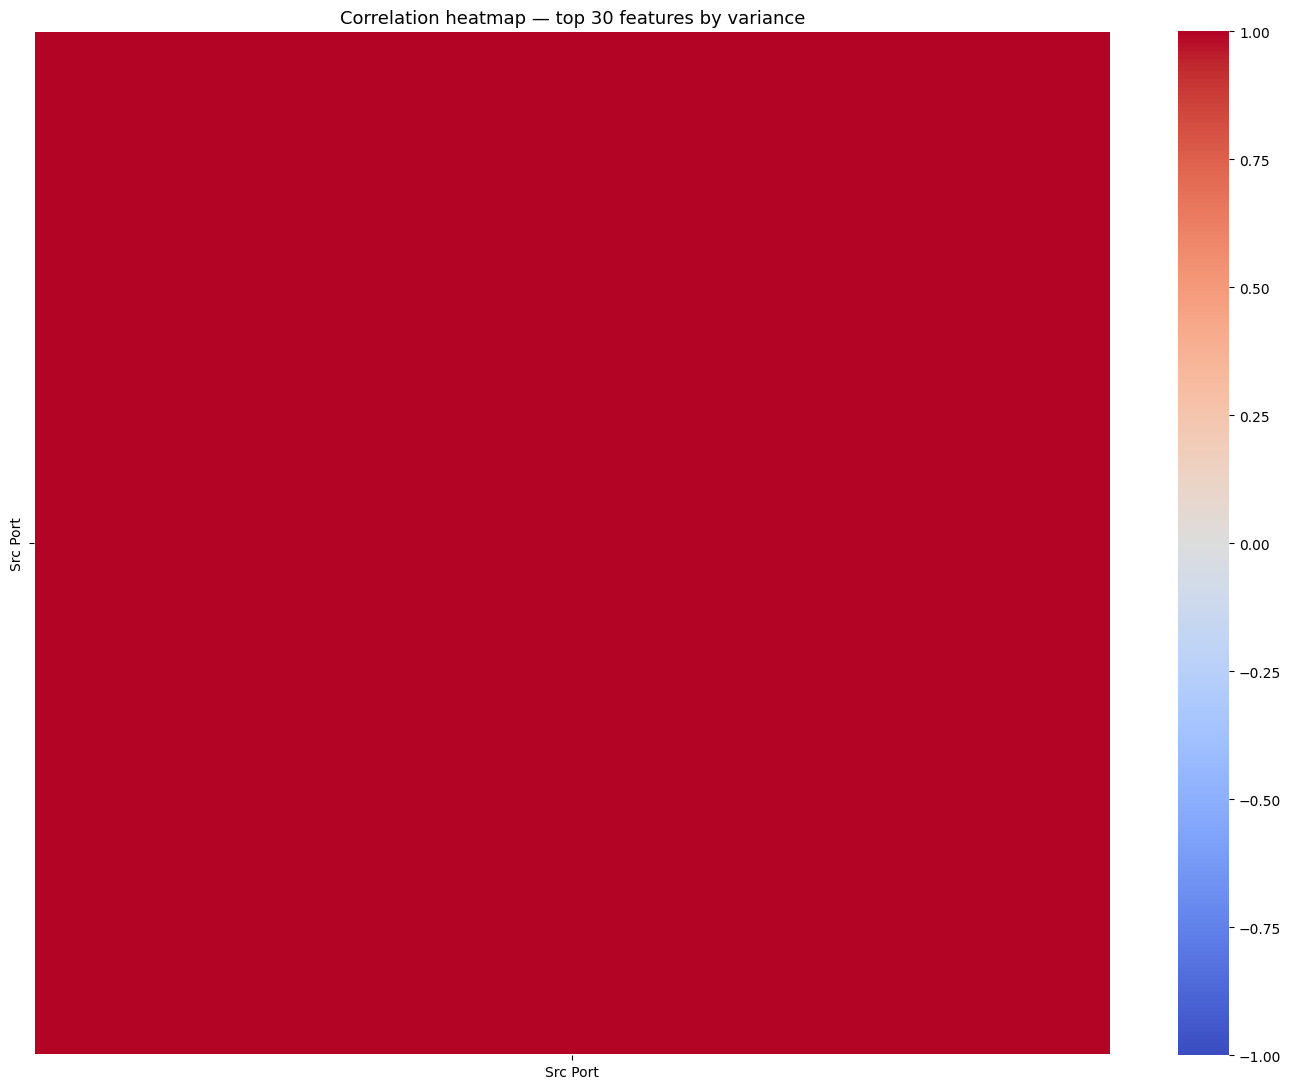

Heatmap saved to data/processed/corr_heatmap.png


In [17]:
# Sample 10k rows for speed
sample_for_corr = df_clean_preview.select_dtypes(include=[np.number]).dropna().sample(
    n=min(10_000, len(df_clean_preview)), random_state=42
)

corr = sample_for_corr.corr().abs()

# Extract upper triangle pairs with correlation > 0.95
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if pd.notna(upper.loc[row, col]) and upper.loc[row, col] > 0.95
]
high_corr.sort(key=lambda x: -x[2])

print(f'=== Highly correlated feature pairs (|r| > 0.95): {len(high_corr)} pairs ===')
for a, b, r in high_corr:
    print(f'  r={r:.4f}  {a}  ↔  {b}')

# Also plot a condensed heatmap (top 30 features by variance)
top30 = sample_for_corr.var().nlargest(30).index
plt.figure(figsize=(14, 11))
sns.heatmap(
    sample_for_corr[top30].corr(),
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.3, annot=False
)
plt.title('Correlation heatmap — top 30 features by variance', fontsize=13)
plt.tight_layout()
plt.savefig('../data/processed/corr_heatmap.png', dpi=120)
plt.show()
print('Heatmap saved to data/processed/corr_heatmap.png')

In [18]:
numeric_clean = df_clean_preview.select_dtypes(include=[np.number])

p999 = numeric_clean.quantile(0.999)
p001 = numeric_clean.quantile(0.001)
col_max = numeric_clean.max()
col_min = numeric_clean.min()

# Ratio of max to 99.9th percentile — high ratio = extreme outliers
max_ratio = (col_max / p999.replace(0, np.nan)).abs()

outlier_check = pd.DataFrame({
    'p0.1%' : p001,
    'p99.9%': p999,
    'min'   : col_min,
    'max'   : col_max,
    'max/p99.9': max_ratio
}).sort_values('max/p99.9', ascending=False)

print('=== Top 20 features with largest outlier ratio (max / 99.9th pct) ===')
print(outlier_check.head(20).to_string())

=== Top 20 features with largest outlier ratio (max / 99.9th pct) ===
          p0.1%     p99.9%    min        max  max/p99.9
Src Port 0.0000 65505.0000 0.0000 65535.0000     1.0005


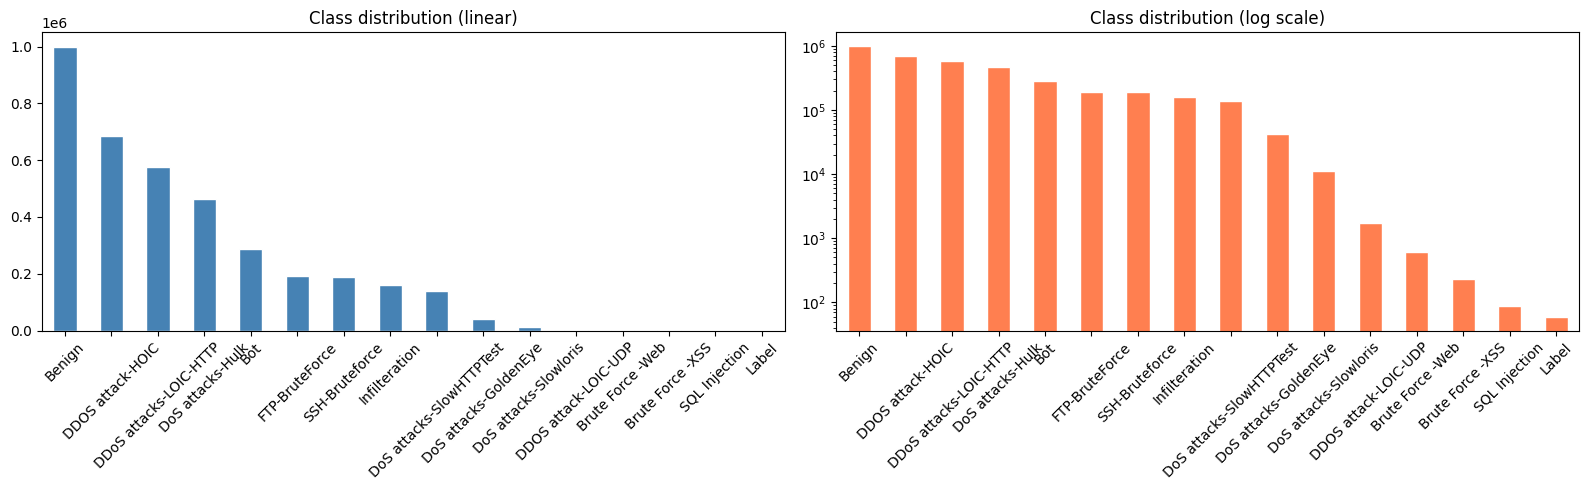

Class counts:
Label
Benign                      1000000
DDOS attack-HOIC             686012
DDoS attacks-LOIC-HTTP       576191
DoS attacks-Hulk             461912
Bot                          286191
FTP-BruteForce               193360
SSH-Bruteforce               187589
Infilteration                161934
DoS attacks-SlowHTTPTest     139890
DoS attacks-GoldenEye         41508
DoS attacks-Slowloris         10990
DDOS attack-LOIC-UDP           1730
Brute Force -Web                611
Brute Force -XSS                230
SQL Injection                    87
Label                            59


In [19]:
os.makedirs('../data/processed', exist_ok=True)

label_counts = df[LABEL_COL].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Linear scale
label_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Class distribution (linear)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)

# Log scale
label_counts.plot(kind='bar', ax=axes[1], color='coral', edgecolor='white', logy=True)
axes[1].set_title('Class distribution (log scale)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../data/processed/class_distribution.png', dpi=120)
plt.show()

print('Class counts:')
print(label_counts.to_string())

In [20]:
print('=' * 60)
print('PREPROCESSING CHECKLIST')
print('=' * 60)

print(f'\n[1] LABEL COLUMN      : "{LABEL_COL}"')
print(f'    BENIGN label      : "{BENIGN_LABEL}"')
print(f'    Attack labels     : {[l for l in df[LABEL_COL].unique() if l != BENIGN_LABEL]}')

print(f'\n[2] SHAPE             : {df.shape}')
print(f'    Numeric cols      : {len(df.select_dtypes(include=[np.number]).columns)}')
print(f'    Object cols (excl label): {len(object_cols_no_label)}')

print(f'\n[3] MISSING VALUES')
total_nan = df.isnull().sum().sum()
print(f'    Total NaN cells   : {total_nan:,}')
nan_col_names = nan_cols.index.tolist() if len(nan_cols) > 0 else []
print(f'    Affected columns  : {nan_col_names}')

print(f'\n[4] INFINITIES')
total_inf = int(np.isinf(df.select_dtypes(include=[np.number])).sum().sum())
inf_col_names = inf_cols.index.tolist() if len(inf_cols) > 0 else []
print(f'    Total Inf cells   : {total_inf:,}')
print(f'    Affected columns  : {inf_col_names}')

print(f'\n[5] ZERO-VAR COLUMNS  : {zero_var}')
print(f'\n[6] OBJECT COLS TO DROP/ENCODE: {object_cols_no_label}')
print(f'\n[7] HIGH-CORR PAIRS   : {len(high_corr)} pairs with |r| > 0.95')
print(f'    (top 5):', [(a, b) for a, b, _ in high_corr[:5]])

print('\n' + '=' * 60)
print('Send this output + all REPORT BACK sections to Claude.')
print('=' * 60)

PREPROCESSING CHECKLIST

[1] LABEL COLUMN      : "Label"
    BENIGN label      : "Benign"
    Attack labels     : ['Bot', 'DoS attacks-SlowHTTPTest', 'DoS attacks-Hulk', 'Label', 'Brute Force -Web', 'Brute Force -XSS', 'SQL Injection', 'DDoS attacks-LOIC-HTTP', 'Infilteration', 'DoS attacks-GoldenEye', 'DoS attacks-Slowloris', 'FTP-BruteForce', 'SSH-Bruteforce', 'DDOS attack-LOIC-UDP', 'DDOS attack-HOIC']

[2] SHAPE             : (3748294, 84)
    Numeric cols      : 1
    Object cols (excl label): 82

[3] MISSING VALUES
    Total NaN cells   : 12,292,954
    Affected columns  : ['Flow ID', 'Src Port', 'Src IP', 'Dst IP', 'Flow Byts/s']

[4] INFINITIES
    Total Inf cells   : 0
    Affected columns  : []

[5] ZERO-VAR COLUMNS  : []

[6] OBJECT COLS TO DROP/ENCODE: ['Dst Port', 'Protocol', 'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd